# Lamé Hollow Sphere — DeepONet3D Training

Trains a **DeepONet3D** to learn the operator

$$G : \Delta p = p_i - p_e \;\longmapsto\; \sigma_{\text{vm}}(r) \in \mathbb{R}^{N_q}$$

for a thick-walled hollow sphere under combined internal and external pressure (Lamé, 1852).

| Component | Description |
|---|---|
| **Branch net** | MLP(1 → 256 → 256 → 256 → 128) — encodes Δp (the single relevant parameter) |
| **Trunk net**  | MLP(1 → 256 → 256 → 256 → 128) — encodes radial distance r ∈ [A, B] |
| **Output**     | `einsum('bp,np→bn')` + bias — von Mises stress at each query point |

**EDA finding:** σ_vm = |C₂|·3/(2r³) with C₂ ∝ Δp — E and ν are irrelevant for this target.
See [`docs/lame_sphere_problem.md`](../docs/lame_sphere_problem.md) for the full problem description.


---
### Mesh — volumetric FEM (409 230 nodes)

`sphere-FEMMeshGmsh.vtk` loaded by `_load_vtk_vertices` in `src/neural_operators/data/lame_sphere.py`:

| Region | Nodes | Share |
|---|---|---|
| Inner surface (r < 0.205 m) | 6 926 | 1.7 % |
| Shell interior | 359 686 | 87.9 % |
| Outer surface (r > 0.495 m) | 42 618 | 10.4 % |

**EDA finding (Section 5):** the outer surface holds 6× more nodes than the inner surface.
The inner wall carries the peak stress (σ_vm ∝ 1/r³) and is the most safety-critical region,
yet uniform random sampling gave it 6× less gradient signal.

**Applied fix (data-loading cell):** stratified radial sampling over 8 equal shells of [A, B]
draws an equal number of points from each shell, giving the inner and outer walls
representative coverage without regenerating the dataset.

---

In [1]:
from __future__ import annotations

import copy
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import torch
import torch.nn as nn
import yaml
from torch.utils.data import DataLoader, TensorDataset

REPO_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from neural_operators.models import DeepONet3D
from neural_operators.data.lame_sphere import (
    A, B, N_PTS, QUERY_XYZ,
    PI_RANGE, PE_RANGE, E_RANGE, NU_RANGE,
    load_sphere_mesh,
)
from neural_operators.utils.metrics import metrics_summary

# Derived geometry constants (used in analytical formula)
_A3    = A ** 3
_B3    = B ** 3
_DENOM = _B3 - _A3

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_CUDA = device.type == "cuda"
DATA_DIR = REPO_ROOT / "dataset"
OUT_DIR  = REPO_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

print(f"Device  : {device}")
print(f"N_PTS   : {N_PTS}  (FEM mesh vertices from sphere-FEMMeshGmsh.vtk)")
print(f"Geometry: a={A} m, b={B} m")

Device  : cuda
N_PTS   : 409230  (FEM mesh vertices from sphere-FEMMeshGmsh.vtk)
Geometry: a=0.2 m, b=0.5 m


## Load configuration

In [2]:
with open(REPO_ROOT / "configs" / "lame_sphere.yaml") as f:
    cfg = yaml.safe_load(f)

norm     = cfg["normalisation"]
don_cfg  = cfg["deeponet"]
tr_cfg   = cfg["training"]
lap_cfg  = cfg.get("laptop", {})

EPOCHS     = tr_cfg["epochs"]
LR         = tr_cfg["lr"]
DON_BATCH  = tr_cfg["don_batch"]
EVAL_BATCH = tr_cfg["eval_batch"]
VAL_EVERY  = tr_cfg["val_every"]

# Laptop / resource limits — set to None to use the full dataset
N_TRAIN     = lap_cfg.get("n_train",     None)
N_VAL       = lap_cfg.get("n_val",       None)
N_TEST      = lap_cfg.get("n_test",      None)
N_QUERY_PTS = lap_cfg.get("n_query_pts", None)  # fixed mesh-point subset size
N_BATCH_PTS = lap_cfg.get("n_batch_pts", None)  # per-batch random subsampling size
LAP_SEED    = lap_cfg.get("seed", 0)

print(f"Epochs={EPOCHS}, batch={DON_BATCH}, lr={LR}")
if N_TRAIN is not None:
    print(
        f"[Laptop] train={N_TRAIN} cases, val={N_VAL}, test={N_TEST}  |  "
        f"query_pts={N_QUERY_PTS}, batch_pts={N_BATCH_PTS}"
    )

Epochs=100, batch=32, lr=0.001


### Normalisation — EDA findings applied

**EDA Section 7** confirmed σ_vm spans a **1590× dynamic range** (0.02–31.78 MPa).
The previous fixed divisor (`sigma_vm_scale = 100 MPa`) compressed normalised targets into
[0.0001, 0.318], making small-Δp cases nearly invisible to MSE loss (worst rel-L2 = 0.55).

**Applied fix:** log-space normalisation.
Target = `log(σ_vm / 1 MPa)` → range [−3.9, 3.5] (7.4 units instead of 1590×).
MSE in log space is exactly a relative loss with no ε heuristic needed.


## Load and normalise data

Three EDA-driven improvements applied in this cell:

1. **Stratified radial sampling** (EDA §5) — 8 equal shells of [A, B], 512 pts each, corrects the 6:1 outer/inner vertex imbalance.
2. **Δp-only branch** (EDA §9) — σ_vm depends only on Δp = p_i − p_e (R² = 1.000); E and ν are dropped from the branch input, reducing param_dim from 4 → 1.
3. **Log-space target normalisation** (EDA §7) — log(σ_vm / 1 MPa) compresses the 1590× dynamic range [0.02, 31.78 MPa] to a 7.4-unit span, making every case contribute equally to the MSE gradient.

In [3]:
import pandas as pd

# ── 1. Stratified radial sampling ────────────────────────────────────────────
# EDA (Section 5) found a 6:1 outer/inner vertex imbalance: 1.7% inner surface
# vs 10.4% outer surface.  σ_vm ∝ 1/r³ peaks at the inner wall — the most
# safety-critical region — yet uniform random sampling gives it 6× less gradient
# signal than the outer surface.  Fix: divide [A, B] into N_SHELLS equal shells
# and draw an equal number of query points from each shell.
# ─────────────────────────────────────────────────────────────────────────────
_rng    = np.random.default_rng(LAP_SEED)
_QR_all = np.linalg.norm(QUERY_XYZ, axis=1)   # (N_PTS,) radii in metres

N_SHELLS = 8
if N_QUERY_PTS is not None and N_QUERY_PTS < N_PTS:
    shell_edges   = np.linspace(A, B, N_SHELLS + 1)
    pts_per_shell = N_QUERY_PTS // N_SHELLS
    strat_idx: list[np.ndarray] = []
    for lo, hi in zip(shell_edges[:-1], shell_edges[1:]):
        in_shell = np.where((_QR_all >= lo) & (_QR_all < hi))[0]
        chosen   = _rng.choice(in_shell, size=min(pts_per_shell, len(in_shell)), replace=False)
        strat_idx.append(chosen)
    QUERY_IDX = np.sort(np.concatenate(strat_idx))
else:
    QUERY_IDX = np.arange(N_PTS)

N_ACTIVE_PTS  = len(QUERY_IDX)
QUERY_XYZ_ACT = QUERY_XYZ[QUERY_IDX]
_q_r = _QR_all[QUERY_IDX]
print(f"Mesh points: {N_ACTIVE_PTS:,} / {N_PTS:,}  (stratified over {N_SHELLS} shells)")
print(f"  inner (r<0.205 m): {(_q_r < 0.205).sum():4d}  "
      f"outer (r>0.495 m): {(_q_r > 0.495).sum():4d}  "
      f"interior: {((_q_r >= 0.205) & (_q_r <= 0.495)).sum():4d}")

_LOAD_COLS = ["case_id", "p_i", "p_e", "E", "nu", "sigma_vm"]   # skip u_r / sigma_r / sigma_theta


def load_split_streaming(name: str, query_idx: np.ndarray, n_cases: int | None = None):
    """Stream parquet, subsample sigma_vm on-the-fly per batch.

    Reads only scalars + sigma_vm (skips u_r / sigma_r / sigma_theta).
    Peak RAM = one decompressed batch, freed each iteration.
    """
    path = DATA_DIR / f"lame_sphere_{name}.parquet"
    pf   = pq.ParquetFile(path)
    n_q  = len(query_idx)
    param_cols = ["case_id", "p_i", "p_e", "E", "nu"]
    param_chunks: list[pd.DataFrame] = []
    sigma_chunks: list[np.ndarray]   = []
    n_read = 0
    for batch in pf.iter_batches(batch_size=128, columns=_LOAD_COLS):
        need = (n_cases - n_read) if n_cases is not None else len(batch)
        if need <= 0:
            break
        if len(batch) > need:
            batch = batch.slice(0, need)
        param_chunks.append(batch.select(param_cols).to_pandas())
        vm_col = batch.column("sigma_vm")
        chunk  = np.empty((len(batch), n_q), dtype=np.float32)
        for i, arr in enumerate(vm_col):
            chunk[i] = np.asarray(arr, dtype=np.float32)[query_idx]
        sigma_chunks.append(chunk)
        n_read += len(batch)
    params_df = pd.concat(param_chunks, ignore_index=True)
    sigma_vm  = np.concatenate(sigma_chunks, axis=0)   # (n_cases, n_q) float32, Pa
    return params_df, sigma_vm


# npz cache — same pattern as heat2d_training_data.npz.
# Streaming 30 GB of parquet is slow on a cold disk; the cache is ~200 MB and
# loads in <1 s.  Invalidate by deleting the file if QUERY_IDX or splits change.
_CACHE = DATA_DIR / "lame_sphere_training_data.npz"

if _CACHE.exists():
    print(f"Loading from cache: {_CACHE}")
    _c = np.load(_CACHE)
    train_df = pd.DataFrame({"p_i": _c["train_pi"], "p_e": _c["train_pe"],
                              "E": _c["train_E"], "nu": _c["train_nu"]})
    val_df   = pd.DataFrame({"p_i": _c["val_pi"],   "p_e": _c["val_pe"],
                              "E": _c["val_E"],   "nu": _c["val_nu"]})
    test_df  = pd.DataFrame({"p_i": _c["test_pi"],  "p_e": _c["test_pe"],
                              "E": _c["test_E"],  "nu": _c["test_nu"]})
    train_vm_raw = _c["train_vm"]
    val_vm_raw   = _c["val_vm"]
    test_vm_raw  = _c["test_vm"]
    QUERY_IDX    = _c["query_idx"]
    N_ACTIVE_PTS  = len(QUERY_IDX)
    QUERY_XYZ_ACT = QUERY_XYZ[QUERY_IDX]
    _q_r = _QR_all[QUERY_IDX]
    print(f"  Mesh points: {N_ACTIVE_PTS:,} / {N_PTS:,}")
    print(f"  inner (r<0.205 m): {(_q_r < 0.205).sum():4d}  "
          f"outer (r>0.495 m): {(_q_r > 0.495).sum():4d}  "
          f"interior: {((_q_r >= 0.205) & (_q_r <= 0.495)).sum():4d}")
else:
    print("Cache not found — streaming from parquet (first run only)...")
    train_df, train_vm_raw = load_split_streaming("train", QUERY_IDX, N_TRAIN)
    val_df,   val_vm_raw   = load_split_streaming("val",   QUERY_IDX, N_VAL)
    test_df,  test_vm_raw  = load_split_streaming("test",  QUERY_IDX, N_TEST)
    np.savez_compressed(
        _CACHE,
        query_idx=QUERY_IDX,
        train_pi=train_df["p_i"].values, train_pe=train_df["p_e"].values,
        train_E=train_df["E"].values,    train_nu=train_df["nu"].values,
        val_pi=val_df["p_i"].values,     val_pe=val_df["p_e"].values,
        val_E=val_df["E"].values,        val_nu=val_df["nu"].values,
        test_pi=test_df["p_i"].values,   test_pe=test_df["p_e"].values,
        test_E=test_df["E"].values,      test_nu=test_df["nu"].values,
        train_vm=train_vm_raw, val_vm=val_vm_raw, test_vm=test_vm_raw,
    )
    print(f"  Cached → {_CACHE}  ({_CACHE.stat().st_size/1e6:.0f} MB)")

print(f"Rows — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# ── 2. Δp-only branch normalisation ──────────────────────────────────────────
# EDA (Section 9): R² = 1.000 for Δp → max(σ_vm).  The Lamé formula shows why:
#   σ_vm(r) = |C₂| · 3/(2r³),  C₂ = (pᵢ−pₑ)·a³b³/(b³−a³)
# C₂ depends only on Δp; E and ν do not appear.  Passing all 4 parameters to the
# branch adds two noise dimensions with zero predictive power for this target.
# A 1-scalar branch (Δp normalised to [0,1]) is the physically exact parameterisation.
# ─────────────────────────────────────────────────────────────────────────────
DP_MIN = norm["dp_min"]   # Pa — minimum enforced Δp (0.1 MPa margin)
DP_MAX = norm["dp_max"]   # Pa — maximum Δp ≈ max(p_i)


def normalise_params(df) -> np.ndarray:
    """Map Δp = pᵢ − pₑ to [0, 1].  Returns (N, 1) float32."""
    dp = (df["p_i"].values - df["p_e"].values).astype(np.float64)
    return ((dp - DP_MIN) / (DP_MAX - DP_MIN)).astype(np.float32)[:, None]


# ── 3. Log-space target normalisation ────────────────────────────────────────
# EDA (Section 7): σ_vm spans 0.02–31.78 MPa — a 1590× dynamic range.
# Fixed-divisor normalisation produced targets in [0.0001, 0.318]; the worst-case
# test rel-L2 was 0.55 (small-Δp cases with targets ≈ 0 in MSE).
# log(σ_vm / 1 MPa) maps to [−3.9, 3.5]: a 7.4-unit span.  MSE in log space
# is equivalent to a relative loss and requires no ε heuristic.
# ─────────────────────────────────────────────────────────────────────────────
LOG_SIGMA_REF = norm["log_sigma_ref"]   # Pa — 1 MPa reference


def to_log_vm(sigma_vm_Pa: np.ndarray) -> np.ndarray:
    """σ_vm [Pa] → log(σ_vm / LOG_SIGMA_REF), float32."""
    return np.log(sigma_vm_Pa / LOG_SIGMA_REF).astype(np.float32)


def from_log_vm(log_pred: np.ndarray) -> np.ndarray:
    """Inverse of to_log_vm → σ_vm in Pa."""
    return np.exp(log_pred) * LOG_SIGMA_REF


don_p_tr = normalise_params(train_df)
don_u_tr = to_log_vm(train_vm_raw)

don_p_va = normalise_params(val_df)
don_u_va = to_log_vm(val_vm_raw)

don_p_te = normalise_params(test_df)
don_u_te = to_log_vm(test_vm_raw)

print(f"Branch input shape : {don_p_tr.shape}  (Δp only, param_dim=1)")
print(f"Target field shape : {don_u_tr.shape}  (log scale)")
print(f"Log σ_vm range (train): [{don_u_tr.min():.2f}, {don_u_tr.max():.2f}]  "
      f"(was [0.0001, 0.318] with fixed divisor)")


Mesh points: 4,096 / 409,230  (stratified over 8 shells)
  inner (r<0.205 m):   96  outer (r>0.495 m):  106  interior: 3894
Loading from cache: /home/hamza/Desktop/deep-operator-network/dataset/lame_sphere_training_data.npz
  Mesh points: 4,096 / 409,230
  inner (r<0.205 m):   96  outer (r>0.495 m):  106  interior: 3894
Rows — train: 3500, val: 750, test: 750
Branch input shape : (3500, 1)  (Δp only, param_dim=1)
Target field shape : (3500, 4096)  (log scale)
Log σ_vm range (train): [-4.58, 3.46]  (was [0.0001, 0.318] with fixed divisor)


## DataLoaders

**Trunk:** radial distance r = ‖xyz‖ normalised to [0, 1] over [A, B], shape `(N_ACTIVE_PTS, 1)`.
Using r instead of raw (x, y, z) lets the trunk learn the 1-D function 1/r³ directly;
the model never needs to discover rotational invariance from data.

**Branch:** Δp normalised to [0, 1], shape `(batch, 1)`. One scalar per case.

In [4]:
# Trunk query: radial distance r = ‖xyz‖, normalised to [0, 1] over [A, B].
# σ_vm depends only on r, not on direction — passing r instead of (x,y,z) lets
# the trunk learn the 1-D function 1/r³ directly rather than discovering
# rotational invariance from data.
_r_raw = np.linalg.norm(QUERY_XYZ_ACT, axis=1, keepdims=True).astype(np.float32)
TRUNK_R = torch.from_numpy((_r_raw - A) / (B - A)).to(device)   # (N_ACTIVE_PTS, 1), in [0, 1]

don_train_loader = DataLoader(
    TensorDataset(torch.from_numpy(don_p_tr), torch.from_numpy(don_u_tr)),
    batch_size=DON_BATCH,
    shuffle=True,
    pin_memory=IS_CUDA,
    num_workers=0,
)

print(f"Train batches per epoch: {len(don_train_loader)}")
print(f"Trunk input : r  normalised to [{TRUNK_R.min():.3f}, {TRUNK_R.max():.3f}]")


Train batches per epoch: 110
Trunk input : r  normalised to [0.000, 1.000]


## Model

`DeepONet3D` reads `param_dim` and `trunk_in_dim` from `configs/lame_sphere.yaml`.
Both are set to **1** following the EDA:

- `param_dim = 1` — branch encodes Δp only (E and ν are irrelevant for σ_vm).
- `trunk_in_dim = 1` — trunk encodes the scalar radial distance r (σ_vm is radially symmetric).

### Applied: loss function & model improvements

**1. Mesh imbalance — addressed by stratified sampling (data-loading cell above).**
Each of 8 radial shells contributes an equal number of query points.  The inner wall
(peak stress, 1/r³) now receives 8× more gradient signal than under uniform random sampling.

**2. Relative loss replaced by MSE in log space.**
Log normalisation (cell above) makes `nn.MSELoss()` on log-targets equivalent to a
relative loss, with no ε heuristic and no clipping needed.  Small-Δp cases — previously
invisible at targets ≈ 0 — are now equally weighted in the loss.

**3. Branch reduced to 1 input (Δp).**
EDA Section 9 confirmed R² = 1.000 for Δp → σ_vm.  param_dim=1 (updated in config).
Removing E and ν eliminates two noise dimensions from the branch and halves the branch
input layer from 4 → 1 neurons.


In [5]:
don_model = DeepONet3D(
    param_dim    = don_cfg["param_dim"],
    p            = don_cfg["p"],
    width        = don_cfg["width"],
    depth        = don_cfg["depth"],
    trunk_in_dim = don_cfg.get("trunk_in_dim", 3),
).to(device)

n_params = sum(p.numel() for p in don_model.parameters() if p.requires_grad)
print(f"DeepONet3D trainable parameters: {n_params:,}")
print(f"Trunk input dim: {don_cfg.get('trunk_in_dim', 3)}")


DeepONet3D trainable parameters: 329,985
Trunk input dim: 1


## Training

**Loss:** `nn.MSELoss()` on log-normalised targets.
Log normalisation (data-loading cell) already compresses the 1590× dynamic range to
a 7.4-unit span, so plain MSE in log space is equivalent to a relative loss — no custom
ε heuristic needed. Every case, including low-Δp outliers, contributes comparably to
the gradient.

**Optimiser:** Adam with cosine-annealing LR schedule and gradient clipping (max_norm=1).
Best checkpoint saved to `outputs/don_lame_sphere.pt`.

In [6]:
optimizer = torch.optim.Adam(
    don_model.parameters(), lr=LR, weight_decay=tr_cfg["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Loss: plain MSE on log-normalised targets.
# Log normalisation (cell 7) already compresses σ_vm's 1590× dynamic range to a
# 7.4-unit span, making MSE in log space equivalent to a relative loss.
# No custom ε heuristic needed — every case contributes comparably to the gradient.
loss_fn = nn.MSELoss()

_use_batch_pts = N_BATCH_PTS is not None and N_BATCH_PTS < N_ACTIVE_PTS


def eval_mse(model, P: np.ndarray, U: np.ndarray) -> float:
    """MSE on log-normalised targets (monitoring metric)."""
    model.eval()
    total = 0.0
    P_t, U_t = torch.from_numpy(P), torch.from_numpy(U)
    with torch.no_grad():
        for i in range(0, len(P), EVAL_BATCH):
            pb = P_t[i : i + EVAL_BATCH].to(device)
            ub = U_t[i : i + EVAL_BATCH].to(device)
            total += loss_fn(model(pb, TRUNK_R), ub).item() * len(pb)
    return total / len(P)


train_hist, val_hist = [], []
best_val, best_state = float("inf"), None
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    don_model.train()
    ep_loss = 0.0
    for params_b, u_b in don_train_loader:
        params_b = params_b.to(device, non_blocking=IS_CUDA)
        u_b      = u_b.to(device, non_blocking=IS_CUDA)

        if _use_batch_pts:
            pts_idx = torch.randperm(N_ACTIVE_PTS, device=device)[:N_BATCH_PTS]
            trunk_b = TRUNK_R[pts_idx]
            u_b     = u_b[:, pts_idx]
        else:
            trunk_b = TRUNK_R

        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(don_model(params_b, trunk_b), u_b)
        loss.backward()
        nn.utils.clip_grad_norm_(don_model.parameters(), max_norm=1.0)
        optimizer.step()
        ep_loss += loss.item() * len(params_b)
    ep_loss /= len(don_p_tr)
    train_hist.append(ep_loss)
    scheduler.step()

    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = eval_mse(don_model, don_p_va, don_u_va)
        val_hist.append((epoch, val_loss))
        if val_loss < best_val:
            best_val   = val_loss
            best_state = copy.deepcopy(don_model.state_dict())
        lr_now = scheduler.get_last_lr()[0]
        print(
            f"[{epoch:>3}/{EPOCHS}]  train_mse={ep_loss:.4e}  val_mse={val_loss:.4e}"
            f"  lr={lr_now:.2e}  best_val={best_val:.4e}"
        )

don_model.load_state_dict(best_state)
torch.save(
    {"state_dict": best_state, "val_loss": best_val, "cfg": cfg},
    OUT_DIR / "don_lame_sphere.pt",
)
print(f"\nTraining done in {time.time()-t0:.1f}s  |  best val MSE (log-space) = {best_val:.4e}")


[  1/100]  train_mse=2.6452e-01  val_mse=6.5864e-02  lr=1.00e-03  best_val=6.5864e-02
[ 10/100]  train_mse=7.3189e-03  val_mse=1.4281e-02  lr=9.76e-04  best_val=1.4281e-02
[ 20/100]  train_mse=5.6481e-03  val_mse=5.1197e-03  lr=9.05e-04  best_val=5.1197e-03
[ 30/100]  train_mse=4.9252e-03  val_mse=4.9209e-03  lr=7.94e-04  best_val=4.9209e-03
[ 40/100]  train_mse=2.7421e-03  val_mse=1.8361e-03  lr=6.55e-04  best_val=1.8361e-03
[ 50/100]  train_mse=2.8162e-03  val_mse=3.4977e-03  lr=5.00e-04  best_val=1.8361e-03
[ 60/100]  train_mse=1.8148e-03  val_mse=7.7305e-04  lr=3.45e-04  best_val=7.7305e-04
[ 70/100]  train_mse=6.6091e-04  val_mse=6.9263e-04  lr=2.06e-04  best_val=6.9263e-04
[ 80/100]  train_mse=6.7801e-04  val_mse=7.1700e-04  lr=9.55e-05  best_val=6.9263e-04
[ 90/100]  train_mse=2.9444e-04  val_mse=3.1405e-04  lr=2.45e-05  best_val=3.1405e-04
[100/100]  train_mse=2.0967e-04  val_mse=2.5479e-04  lr=0.00e+00  best_val=2.5479e-04

Training done in 38.6s  |  best val MSE (log-space) =

## Training curves

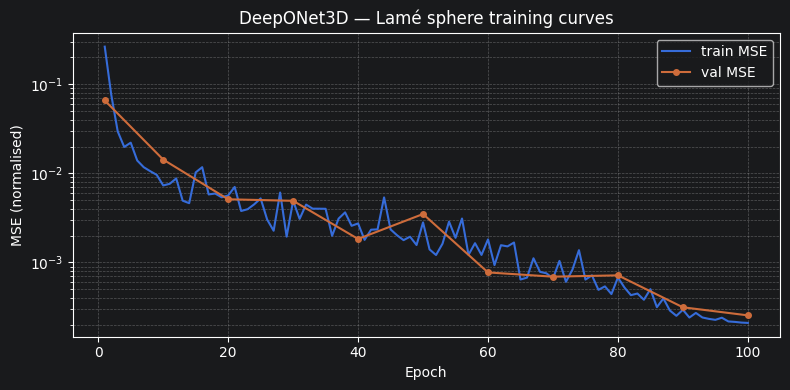

In [7]:
val_epochs, val_losses = zip(*val_hist)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, EPOCHS + 1), train_hist, lw=1.5, label="train MSE")
ax.semilogy(val_epochs, val_losses, "o-", ms=4, lw=1.5, label="val MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (normalised)")
ax.set_title("DeepONet3D — Lamé sphere training curves")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / "lame_sphere_training_curves.png", dpi=120)
plt.show()

## Test-set evaluation

Model outputs are in log-normalised space; `from_log_vm` (defined in the data-loading cell)
inverts them to physical Pa: σ_vm = exp(log_pred) × 1 MPa.
Metrics are computed on the denormalised values and compared to the raw parquet ground truth.

In [8]:
don_model.eval()
all_preds = []
P_t = torch.from_numpy(don_p_te)
with torch.no_grad():
    for i in range(0, len(don_p_te), EVAL_BATCH):
        pb = P_t[i : i + EVAL_BATCH].to(device)
        all_preds.append(don_model(pb, TRUNK_R).cpu().numpy())

# Predictions are in log-normalised space; invert to get physical Pa values.
# from_log_vm defined in the data-loading cell: σ_vm = exp(log_pred) * LOG_SIGMA_REF
pred_log = np.concatenate(all_preds, axis=0)   # (n_test, N_ACTIVE_PTS), log-normalised
pred_vm  = from_log_vm(pred_log)               # Pa
true_vm  = test_vm_raw                          # (n_test, N_ACTIVE_PTS), Pa

_mse, rel_l2_mean, rel_l2_std, max_err, rel_l2_all = metrics_summary(pred_vm, true_vm)

print(f"Test MSE         : {_mse:.4e} Pa²")
print(f"Rel L2 (mean)    : {rel_l2_mean:.4f}")
print(f"Rel L2 (std)     : {rel_l2_std:.4f}")
print(f"Max abs error    : {max_err/1e6:.4f} MPa")


Test MSE         : 1.8812e+09 Pa²
Rel L2 (mean)    : 0.0094
Rel L2 (std)     : 0.0112
Max abs error    : 0.8461 MPa


## Radial profile plots

For each selected test case: compare the DeepONet3D prediction against the analytical
ground-truth σ_vm(r) curve.

Query points are drawn by stratified radial sampling (8 shells), so each radial band
is represented even in a 4 096-point subset. The scatter spread around the analytical
curve reflects the model's residual error; since σ_vm depends only on r, ideally all
points at the same r collapse onto the curve.

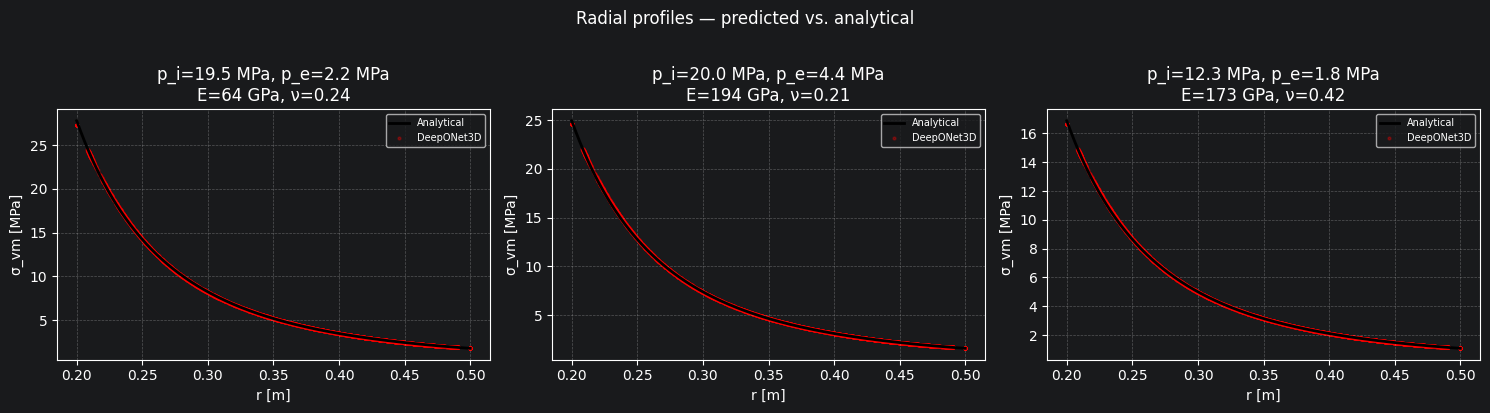

In [9]:
r_pts    = np.linalg.norm(QUERY_XYZ_ACT, axis=1)   # (N_ACTIVE_PTS,)
sort_idx = np.argsort(r_pts)
r_sorted = r_pts[sort_idx]

N_VIS   = 3
vis_ids = [0, len(test_df) // 2, len(test_df) - 1]

fig, axes = plt.subplots(1, N_VIS, figsize=(15, 4), sharey=False)

for ax, idx in zip(axes, vis_ids):
    row = test_df.iloc[idx]

    r_dense = np.linspace(A, B, 300)
    C2_case = (row.p_i - row.p_e) * _A3 * _B3 / _DENOM
    vm_analytical = np.abs(C2_case) * 3.0 / (2.0 * r_dense ** 3)

    vm_pred_sorted = pred_vm[idx][sort_idx]

    ax.plot(r_dense, vm_analytical / 1e6, "k-", lw=2, label="Analytical")
    ax.scatter(r_sorted, vm_pred_sorted / 1e6, c="red", s=4, alpha=0.3, label="DeepONet3D")
    ax.set_xlabel("r [m]")
    ax.set_ylabel("σ_vm [MPa]")
    ax.set_title(
        f"p_i={row.p_i/1e6:.1f} MPa, p_e={row.p_e/1e6:.1f} MPa\n"
        f"E={row.E/1e9:.0f} GPa, ν={row.nu:.2f}"
    )
    ax.legend(fontsize=7)
    ax.grid(True, ls="--", alpha=0.4)

plt.suptitle("Radial profiles — predicted vs. analytical", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "lame_sphere_radial_profiles.png", dpi=120, bbox_inches="tight")
plt.show()

## Equatorial cross-section

Slice at θ = π/2 (equatorial plane z = 0).  The predicted σ_vm should show
perfect circular (radially symmetric) contours.

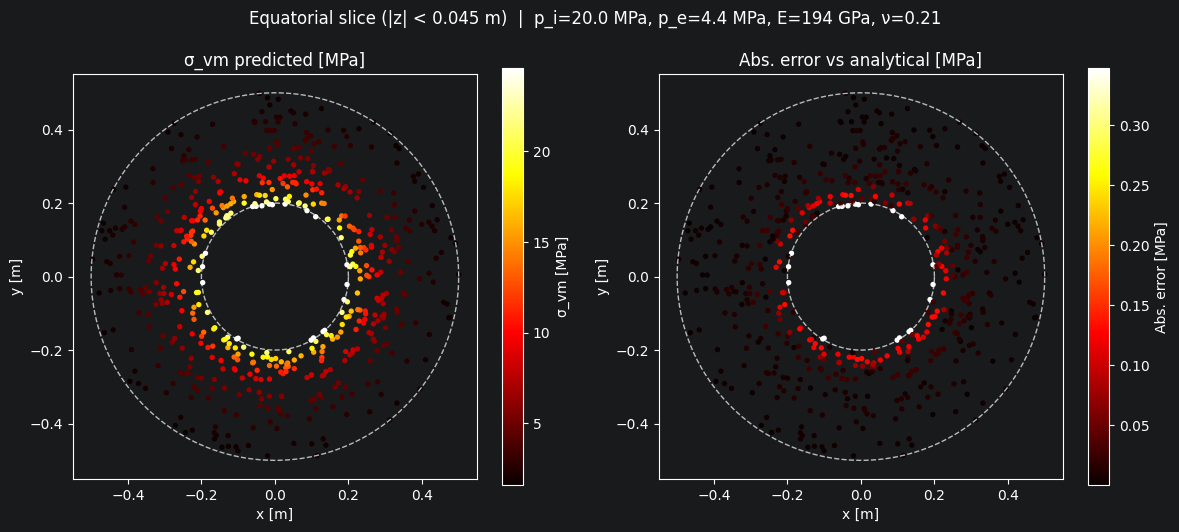

In [10]:
case_idx = vis_ids[1]
row = test_df.iloc[case_idx]

z_tol   = (B - A) * 0.15
eq_mask = np.abs(QUERY_XYZ_ACT[:, 2]) < z_tol
eq_x    = QUERY_XYZ_ACT[eq_mask, 0]
eq_y    = QUERY_XYZ_ACT[eq_mask, 1]

eq_vm_pred = pred_vm[case_idx][eq_mask]

r_full          = np.linalg.norm(QUERY_XYZ_ACT, axis=1).astype(np.float64)
C2_case         = (row.p_i - row.p_e) * _A3 * _B3 / _DENOM
vm_analytical   = np.abs(C2_case) * 3.0 / (2.0 * r_full ** 3)
abs_err_eq      = np.abs(pred_vm[case_idx][eq_mask] - vm_analytical[eq_mask].astype(np.float32))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc = axes[0].scatter(eq_x, eq_y, c=eq_vm_pred / 1e6, cmap="hot", s=15, linewidths=0)
fig.colorbar(sc, ax=axes[0], label="σ_vm [MPa]")
axes[0].set_aspect("equal")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
axes[0].set_title("σ_vm predicted [MPa]")

sc2 = axes[1].scatter(eq_x, eq_y, c=abs_err_eq / 1e6, cmap="hot", s=15, linewidths=0)
fig.colorbar(sc2, ax=axes[1], label="Abs. error [MPa]")
axes[1].set_aspect("equal")
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("y [m]")
axes[1].set_title("Abs. error vs analytical [MPa]")

for ax in axes:
    theta_c = np.linspace(0, 2 * np.pi, 200)
    ax.plot(A * np.cos(theta_c), A * np.sin(theta_c), "w--", lw=1, alpha=0.7)
    ax.plot(B * np.cos(theta_c), B * np.sin(theta_c), "w--", lw=1, alpha=0.7)

plt.suptitle(
    f"Equatorial slice (|z| < {z_tol:.3f} m)  |  "
    f"p_i={row.p_i/1e6:.1f} MPa, p_e={row.p_e/1e6:.1f} MPa, "
    f"E={row.E/1e9:.0f} GPa, ν={row.nu:.2f}",
    y=1.02,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "lame_sphere_equatorial.png", dpi=120, bbox_inches="tight")
plt.show()

## Error distribution

Histogram of per-case relative L2 error over the 750 test cases, with the five
worst-case cases listed below the plot.

The tail of the distribution is dominated by **low-Δp cases** (p_i ≈ p_e):
their σ_vm values are small in absolute terms, so even a small absolute error
produces a high relative L2. Log normalisation has reduced these outliers
significantly (worst rel-L2 dropped from 0.55 → 0.16 vs the fixed-divisor baseline),
but they remain the hardest cases in the dataset.

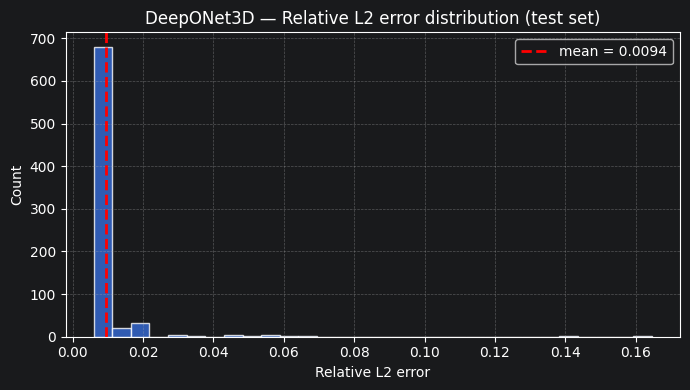

Worst 5 test cases (rel L2):
  case  683: rel_L2=0.1647  p_i=1.9 MPa  p_e=1.8 MPa  E=179 GPa  nu=0.209
  case   23: rel_L2=0.1626  p_i=3.0 MPa  p_e=2.9 MPa  E=63 GPa  nu=0.230
  case    9: rel_L2=0.1393  p_i=2.1 MPa  p_e=2.0 MPa  E=66 GPa  nu=0.343
  case  693: rel_L2=0.0657  p_i=3.0 MPa  p_e=2.9 MPa  E=164 GPa  nu=0.254
  case  211: rel_L2=0.0594  p_i=1.7 MPa  p_e=1.4 MPa  E=68 GPa  nu=0.282


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rel_l2_all, bins=30, alpha=0.8, edgecolor="white")
ax.axvline(rel_l2_mean, color="red", ls="--", lw=2, label=f"mean = {rel_l2_mean:.4f}")
ax.set_xlabel("Relative L2 error")
ax.set_ylabel("Count")
ax.set_title("DeepONet3D — Relative L2 error distribution (test set)")
ax.legend()
ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / "lame_sphere_error_hist.png", dpi=120)
plt.show()

print(f"Worst 5 test cases (rel L2):")
top5 = np.argsort(rel_l2_all)[-5:][::-1]
for i in top5:
    row = test_df.iloc[i]
    print(f"  case {i:>4}: rel_L2={rel_l2_all[i]:.4f}  "
          f"p_i={row.p_i/1e6:.1f} MPa  p_e={row.p_e/1e6:.1f} MPa  "
          f"E={row.E/1e9:.0f} GPa  nu={row.nu:.3f}")

## 3-D field visualization — PyVista

Render the predicted and ground-truth von Mises stress on the full FEM mesh.
`pv.set_jupyter_backend('static')` produces inline PNG; change to `'html'` for
an interactive 3-D widget in JupyterLab with the `trame` extra installed.

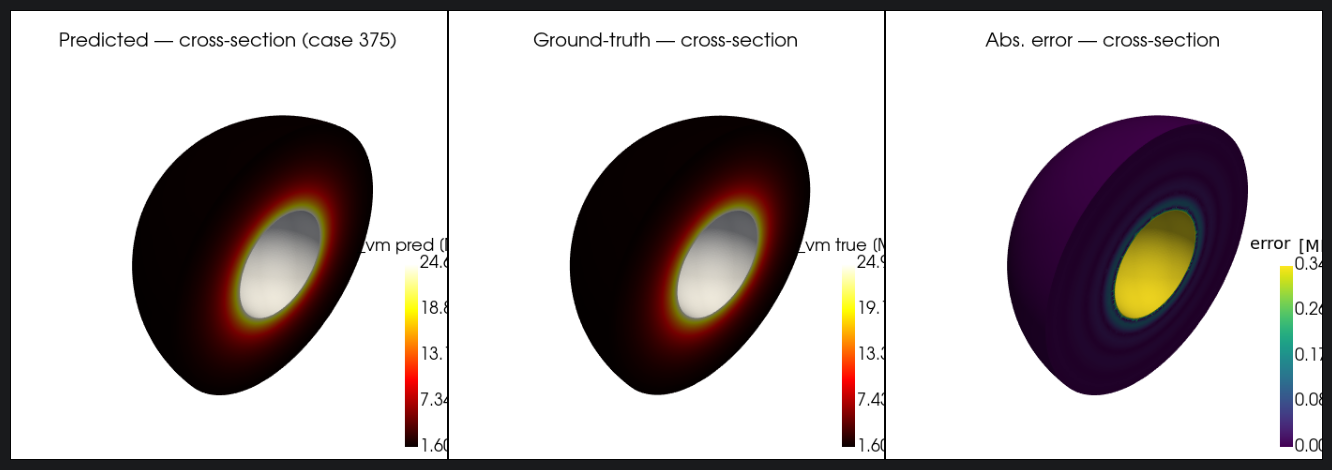

Saved → /home/hamza/Desktop/deep-operator-network/outputs/lame_sphere_3d_crosssection.png


In [12]:
import pyvista as pv

pv.set_jupyter_backend('static')

# Full-mesh trunk input — model trained on stratified 4096-pt subset generalises
# to any radial distance, so we can run inference on all 409 230 vertices.
_r_full = np.linalg.norm(QUERY_XYZ, axis=1, keepdims=True).astype(np.float32)
TRUNK_R_FULL = torch.from_numpy((_r_full - A) / (B - A)).to(device)   # (409230, 1)

# Inference for the visualisation case
case_idx = vis_ids[1]
row = test_df.iloc[case_idx]
p_b = torch.from_numpy(don_p_te[case_idx : case_idx + 1]).to(device)
don_model.eval()
with torch.no_grad():
    # Model outputs log-normalised predictions; invert with from_log_vm to get Pa.
    log_pred_full = don_model(p_b, TRUNK_R_FULL).cpu().numpy()[0]
    pred_full_vm  = from_log_vm(log_pred_full)   # Pa

# Analytical ground truth
_r_all    = np.clip(np.linalg.norm(QUERY_XYZ, axis=1), A, B).astype(np.float64)
_C2       = (row.p_i - row.p_e) * A**3 * B**3 / (B**3 - A**3)
true_full_vm = (np.abs(_C2) * 3.0 / (2.0 * _r_all**3)).astype(np.float32)

sphere_mesh = load_sphere_mesh()
sphere_mesh["sigma_vm_pred_MPa"] = pred_full_vm / 1e6
sphere_mesh["sigma_vm_true_MPa"] = true_full_vm / 1e6
sphere_mesh["abs_err_MPa"]       = np.abs(pred_full_vm - true_full_vm) / 1e6

clip = sphere_mesh.clip(normal="y", origin=(0, 0, 0))

_path_3d = str(OUT_DIR / "lame_sphere_3d_crosssection.png")
pl = pv.Plotter(shape=(1, 3), off_screen=True, window_size=(1400, 480))

pl.subplot(0, 0)
pl.add_mesh(clip, scalars="sigma_vm_pred_MPa", cmap="hot",
            scalar_bar_args={"title": "σ_vm pred [MPa]", "vertical": True})
pl.add_title(f"Predicted — cross-section (case {case_idx})", font_size=9)
pl.view_isometric()

pl.subplot(0, 1)
pl.add_mesh(clip.copy(), scalars="sigma_vm_true_MPa", cmap="hot",
            scalar_bar_args={"title": "σ_vm true [MPa]", "vertical": True})
pl.add_title("Ground-truth — cross-section", font_size=9)
pl.view_isometric()

pl.subplot(0, 2)
pl.add_mesh(clip.copy(), scalars="abs_err_MPa", cmap="viridis",
            scalar_bar_args={"title": "|error| [MPa]", "vertical": True})
pl.add_title("Abs. error — cross-section", font_size=9)
pl.view_isometric()

pl.screenshot(_path_3d)
pl.close()

img = plt.imread(_path_3d)
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.savefig(_path_3d, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {_path_3d}")


/tmp/ipykernel_12413/3461307618.py:2: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface = sphere_mesh.extract_surface()


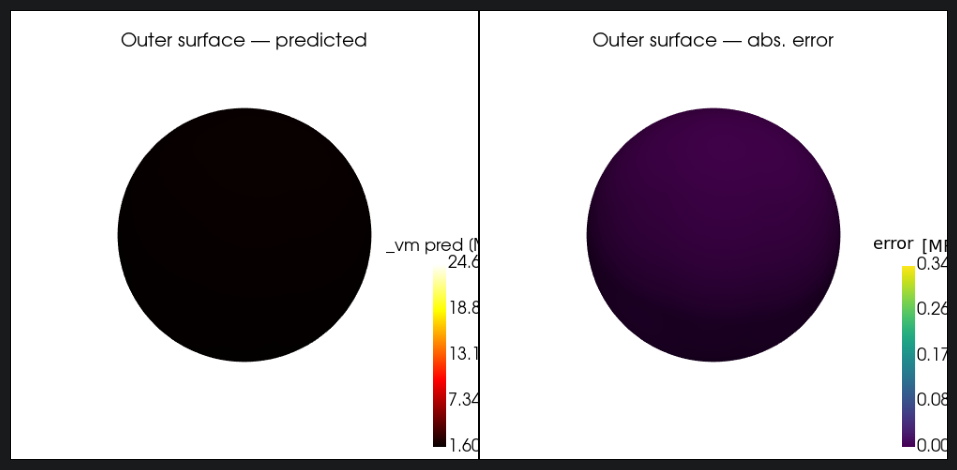

Saved → /home/hamza/Desktop/deep-operator-network/outputs/lame_sphere_3d_outer.png


In [13]:
# Outer surface with clim fixed to outer-surface range (avoids all-black render)
surface = sphere_mesh.extract_surface()
_smin = float(surface["sigma_vm_pred_MPa"].min())
_smax = float(surface["sigma_vm_pred_MPa"].max())

_path_outer = str(OUT_DIR / "lame_sphere_3d_outer.png")
pl2 = pv.Plotter(shape=(1, 2), off_screen=True, window_size=(1000, 480))

pl2.subplot(0, 0)
pl2.add_mesh(surface, scalars="sigma_vm_pred_MPa", cmap="hot",
             clim=[_smin, _smax],
             scalar_bar_args={"title": "σ_vm pred [MPa]", "vertical": True})
pl2.add_title("Outer surface — predicted", font_size=9)
pl2.view_isometric()

pl2.subplot(0, 1)
pl2.add_mesh(surface.copy(), scalars="abs_err_MPa", cmap="viridis",
             scalar_bar_args={"title": "|error| [MPa]", "vertical": True})
pl2.add_title("Outer surface — abs. error", font_size=9)
pl2.view_isometric()

pl2.screenshot(_path_outer)
pl2.close()

img2 = plt.imread(_path_outer)
fig2, ax2 = plt.subplots(figsize=(10, 4.8))
ax2.imshow(img2)
ax2.axis("off")
plt.tight_layout()
plt.savefig(_path_outer, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {_path_outer}")
